# Analyse this naive k curve - constant k

- get average endpoints, average hashes, average reductions

## Imports

In [1]:
import numpy as np
import pandas as pd

t = 10000

## Get data 

In [2]:
## cherry m values
cherry_m_values = []

# read in from each directory the m_values and append to cherry_m_values
for i in range(10):
    # Assuming m_values are stored in a file named 'm_values_{i}.npy'
    m_values = np.load(f'n-32/trial_{i}/m_values.npy')
    cherry_m_values.append(m_values)

curve_m_values = []
for i in range(7):
    m_values = np.load(f'../../n-32/trial_{i}/m_values.npy')
    curve_m_values.append(m_values)


# flat cost
flat_cost_k = []
flat_cost_m_values = []
for i in range(10):
    # Assuming m_values are stored in a file named 'm_values_{i}.npy'
    m_values = np.load(f'../flat-overhead/n-32/trial_{i}/m_values.npy')
    flat_cost_m_values.append(m_values)
    k_values = np.load(f'../flat-overhead/n-32/trial_{i}/kis.npy')
    flat_cost_k.append(k_values)


flat_overhead_k = []
flat_overhead_m_values = []
for i in range(10):
    # Assuming m_values are stored in a file named 'm_values_{i}.npy'
    m_values = np.load(f'../flat-cost/n-32/trial_{i}/m_values.npy')
    flat_overhead_m_values.append(m_values)
    k_values = np.load(f'../flat-cost/n-32/trial_{i}/kis.npy')
    flat_overhead_k.append(k_values)

## vanilla m values
vanilla_m_values = []
for i in range(2):
    m_values = np.load(f'../vanilla/n-32/trial_{i}/m_values.npy')
    vanilla_m_values.append(m_values)

In [3]:
# create dataframe with columns "table", "avg. endpoints", "avg. hashes", "avg. reductions"
df = pd.DataFrame(columns=["table", "avg. endpoints", "avg. hashes", "avg. reductions"])

## get cherry data first
cherry_avg_mt = np.mean([cherry[-1] for cherry in cherry_m_values])
cherry_avg_hashes = np.mean([np.sum(cherry[:-1]) for cherry in cherry_m_values])
cherry_avg_reductions = np.mean([np.sum(cherry[:-1] * 100) for cherry in cherry_m_values])  # since k_i = 100
# df = df.concat({"table": "cherry", "avg. endpoints": cherry_avg_mt, "avg. hashes": cherry_avg_hashes, "avg. reductions": cherry_avg_reductions}, ignore_index=True)
new_row = pd.DataFrame([{
    "table": "cherry", 
    "avg. endpoints": cherry_avg_mt, 
    "avg. hashes": cherry_avg_hashes, 
    "avg. reductions": cherry_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

## get vanilla data
vanilla_avg_mt = np.mean([vanilla[-1] for vanilla in vanilla_m_values])
vanilla_avg_hashes = np.mean([np.sum(vanilla[:-1]) for vanilla in vanilla_m_values])
vanilla_avg_reductions = np.mean([np.sum(vanilla[:-1]) for vanilla in vanilla_m_values])  # since k_i = 1
# df = df.append({"table": "vanilla", "avg. endpoints": vanilla_avg_mt, "avg. hashes": vanilla_avg_hashes, "avg. reductions": vanilla_avg_reductions}, ignore_index=True)
new_row = pd.DataFrame([{
    "table": "vanilla", 
    "avg. endpoints": vanilla_avg_mt, 
    "avg. hashes": vanilla_avg_hashes, 
    "avg. reductions": vanilla_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

# do the same for k curve data
curve_avg_mt = np.mean([curve[-1] for curve in curve_m_values])
curve_avg_hashes = np.mean([np.sum(curve[:-1]) for curve in curve_m_values])
curve_avg_reductions = np.mean([np.sum(curve[:-1] * 100) for curve in curve_m_values])  # since k_i = 100
new_row = pd.DataFrame([{
    "table": "k-curve", 
    "avg. endpoints": curve_avg_mt, 
    "avg. hashes": curve_avg_hashes, 
    "avg. reductions": curve_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

# do the same for flat cost data
## get cherry data first
flat_cost_avg_mt = np.mean([cherry[-1] for cherry in flat_cost_m_values])
flat_cost_avg_hashes = np.mean([np.sum(cherry[:-1]) for cherry in flat_cost_m_values])
# flat_cost_avg_reductions = np.mean([np.sum(cherry[:-1] * 100) for cherry in flat_cost_m_values])  # since k_i = 100


flat_cost_reductions = []
for i in range(10):
    flat_red = []
    for k in range (t):
        flat_red.append(flat_cost_k[i][k] * flat_cost_m_values[i][k])
    flat_cost_reductions.append(np.sum(flat_red))

flat_cost_avg_reductions = np.mean(flat_cost_reductions)

# df = df.concat({"table": "cherry", "avg. endpoints": cherry_avg_mt, "avg. hashes": cherry_avg_hashes, "avg. reductions": cherry_avg_reductions}, ignore_index=True)
new_row = pd.DataFrame([{
    "table": "flat cost", 
    "avg. endpoints": flat_cost_avg_mt, 
    "avg. hashes": flat_cost_avg_hashes, 
    "avg. reductions": flat_cost_avg_reductions
}])
df = pd.concat([df, new_row], ignore_index=True)

# same for flat overhead data
flat_overhead_avg_mt = np.mean([cherry[-1] for cherry in flat_overhead_m_values])
flat_overhead_avg_hashes = np.mean([np.sum(cherry[:-1]) for cherry in flat_overhead_m_values])
# flat_overhead_avg_reductions = np.mean([np.sum(cherry[:-1] * 100) for cherry in flat_overhead_m_values])  # since k_i = 100       
flat_overhead_reductions = []
for i in range(10):
    flat_overhead_red = []
    for k in range (t):
        flat_overhead_red.append(flat_overhead_k[i][k] * flat_overhead_m_values[i][k])
    flat_overhead_reductions.append(np.sum(flat_overhead_red))
flat_overhead_avg_reductions = np.mean(flat_overhead_reductions)
new_row = pd.DataFrame([{
    "table": "flat overhead", 
    "avg. endpoints": flat_overhead_avg_mt, 
    "avg. hashes": flat_overhead_avg_hashes, 
    "avg. reductions": flat_overhead_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

display(df)

C:\Users\Mahfuzah Fariha\AppData\Local\Temp\ipykernel_14996\1755115580.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


,table,avg. endpoints,avg. hashes,avg. reductions
0,cherry,801070.000000,1.476521e+10,1.476521e+12
1,vanilla,686421.000000,1.382320e+10,1.382320e+10
2,k-curve,803043.428571,1.475717e+10,1.475717e+12
3,flat cost,824683.800000,1.490189e+10,5.372939e+12
4,flat overhead,817767.300000,1.485616e+10,3.427865e+12


In [4]:
## total cost
total_cost_cherry = cherry_avg_hashes + (cherry_avg_reductions * 0.05)
total_cost_curve = curve_avg_hashes + (curve_avg_reductions * 0.05)
total_cost_vanilla = vanilla_avg_hashes
total_cost_flat_cost = flat_cost_avg_hashes + (flat_cost_avg_reductions * 0.05)
total_cost_flat_overhead = flat_overhead_avg_hashes + (flat_overhead_avg_reductions * 0.05)

print(f"Total cost of cherry: {total_cost_cherry}")
print(f"Total cost of curve: {total_cost_curve}")
print(f"Total cost of vanilla: {total_cost_vanilla}")
print(f"Total cost of flat cost: {total_cost_flat_cost}")
print(f"Total cost of flat overhead: {total_cost_flat_overhead}")

print(total_cost_cherry / total_cost_curve)

Total cost of cherry: 88591272609.0
Total cost of curve: 88543044626.57144
Total cost of vanilla: 13823204277.0
Total cost of flat cost: 283548849360.43506
Total cost of flat overhead: 186249388763.88004
1.0005446840305974


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


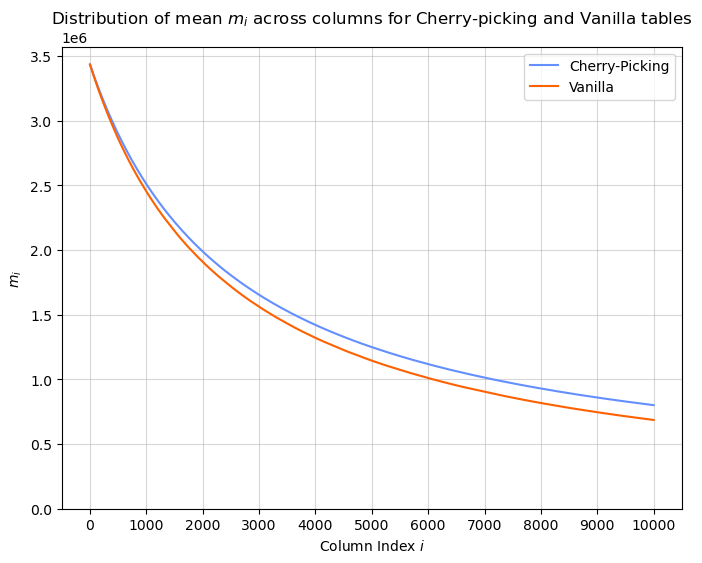

In [5]:
## Plot m_values for cherry and vanilla
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)

ax = plt.gca()
ax.set_ylim(ymin=0)

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)



plt.xlabel(r"Column Index $i$")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
plt.savefig(f"m_values_distribution_t_{t}.eps", format='eps', bbox_inches='tight')
plt.show()

[100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,

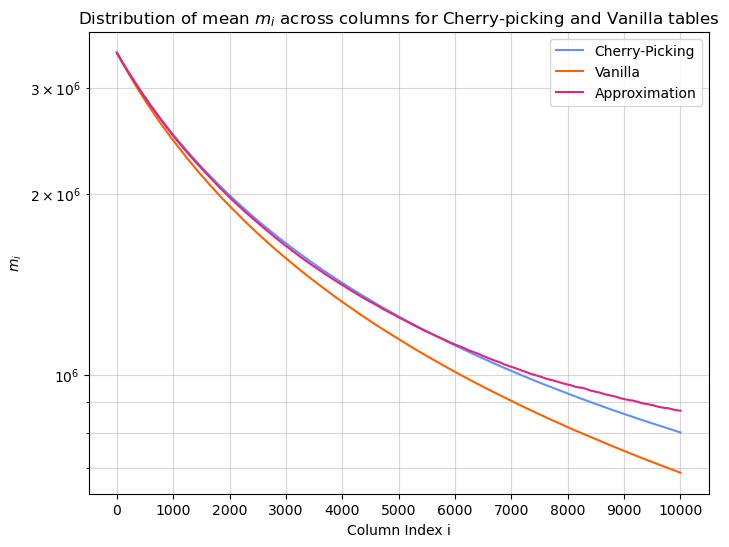

In [6]:
## add on approx
from math import sqrt, pi
from statistics import NormalDist

def calculate_m0(N, t, alpha):
    mttarget = (2 * N) / (t + 2)
    return (alpha * mttarget) / (1 - alpha)

def get_mean(N, m):
    return N - (N * ((1 - 1/N) ** m))

def get_std(N, m):
    # E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m
    
    sqrt_term = (N * ((N - 1) * E2 + E1 - N * E1 ** 2))
    if (sqrt_term < 0):
        return 0
    else:
        return sqrt(sqrt_term)


def approx_mi(N, m, k):
    average = get_mean(N, m)
    sd = get_std(N, m)
    # make a normal distribution from these
    # s = np.random.normal(average, sd, k)
    # # sample k random values from this distribution and take the maximum
    # return max(s)

    m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd
    # m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd
    return m

# Table with the approximation of the occupancy problem
def table_approx(N, t, alpha, k_values):
    m0 = round(calculate_m0(N, t, alpha))
    print(f"m0: {m0}")
    m_values = [m0]
    m = m0

    for i in range(t):
        m = approx_mi(N, m, k_values[i])
        m_values.append(m)

    return m_values

## Plot m_values for cherry and vanilla

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)


# # plot on approx
t = 10000
k_values = [100] * t
print(k_values)
approx_m_values = table_approx(2**32, 10000, 0.8, [100] * t)
# append 9000 0s to the end of approx_m_values to make it the same length as cherry and vanilla m values
plt.plot(x_indicies, approx_m_values, color='#dc267f', label="Approximation", markersize=5)


ax = plt.gca()
ax.set_yscale('log')

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
# plt.savefig(f"m_values_distribution_t_{t}.eps", format='eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


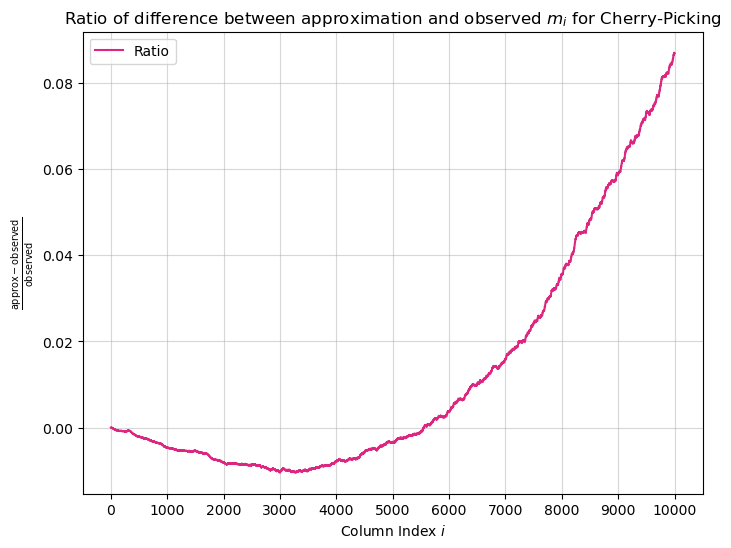

In [24]:
## plot ratio of difference between approximation and cherry-picking 
ratios = []
for i in range(len(cherry_m_values_array)):
    ratio = (approx_m_values[i] - cherry_m_values_array[i]) / cherry_m_values_array[i]
    ratios.append(ratio)

# use box plots and calculate ratio for each trial and plot the distribution of ratios for each column index
# for i in range(len(cherry_m_values_array)):
#     ratio = []
#     for j in range(len(cherry_m_values)):
#         ratio.append((approx_m_values[i] - cherry_m_values[j][i]) / cherry_m_values[j][i])
#     ratios.append(ratio)


plt.figure(figsize=(8, 6))
plt.plot(x_indicies, ratios, color='#dc267f', label="Ratio")
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)
plt.xlabel("Column Index $i$")
plt.ylabel(r"$\frac{\text{approx} - \text{observed}}{\text{observed}}$")
plt.title(r"Ratio of difference between approximation and observed $m_i$ for Cherry-Picking")
plt.legend()
plt.savefig(f"approximation_ratio_n_32.eps", format='eps', bbox_inches='tight')
plt.show()

## plot on all 3 naive k curves



[100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,

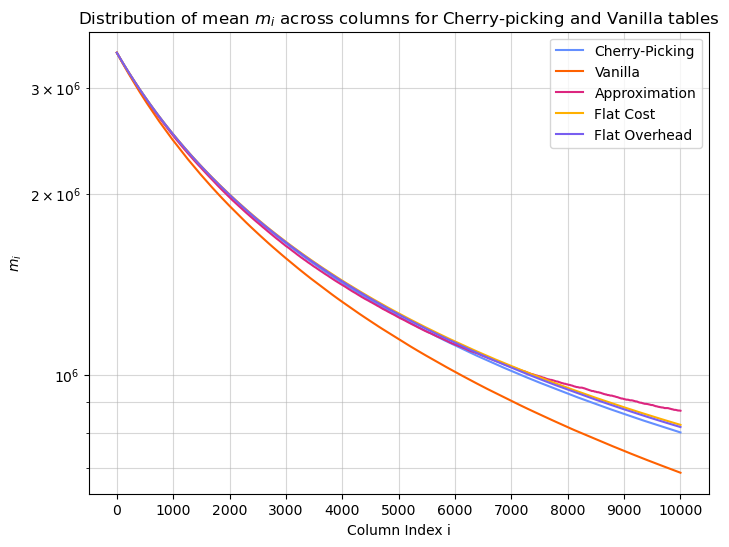

In [8]:
## add on approx
# from math import sqrt, pi
# from statistics import NormalDis

## Plot m_values for cherry and vanilla

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)


# # plot on approx
t = 10000
k_values = [100] * t
print(k_values)
approx_m_values = table_approx(2**32, 10000, 0.8, [100] * t)
# append 9000 0s to the end of approx_m_values to make it the same length as cherry and vanilla m values
plt.plot(x_indicies, approx_m_values, color='#dc267f', label="Approximation", markersize=5)

# plot on flat cost
flat_cost_avg_m_values = np.mean(flat_cost_m_values, axis=0)
plt.plot(x_indicies, flat_cost_avg_m_values, color='#ffb000', label="Flat Cost", markersize=5)

# plot on flat overhead
flat_overhead_avg_m_values = np.mean(flat_overhead_m_values, axis=0)
plt.plot(x_indicies, flat_overhead_avg_m_values, color='#785ef0', label="Flat Overhead", markersize=5)


ax = plt.gca()
ax.set_yscale('log')

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
# plt.savefig(f"m_values_distribution_t_{t}.eps", format='eps', bbox_inches='tight')
plt.show()

m0: 3435287
m0: 3435287


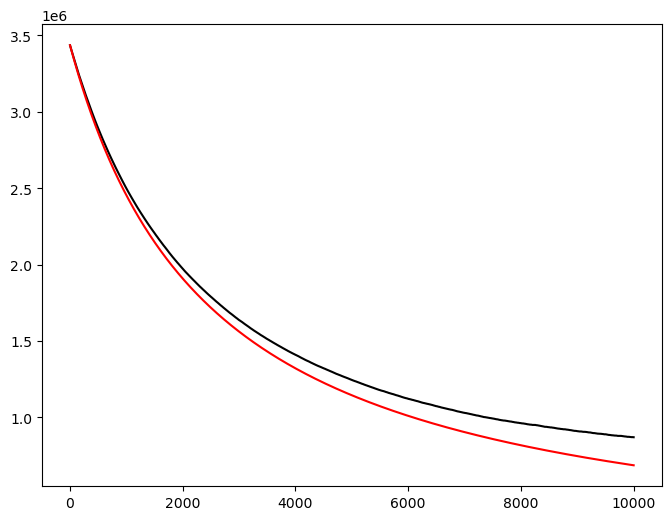

In [9]:
# # plot approx for 2 ** 32
approx_m_Values = table_approx(2**32, 10000, 0.8, [100] * t)
approx_m_van = table_approx(2**32, 10000, 0.8, [1] * t)

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
plt.plot(x_indicies, approx_m_Values, color='#000000', label="Approximation", markersize=5)
plt.plot(x_indicies, approx_m_van, color='#FF0000', label="Approximation Vanilla", markersize=5)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


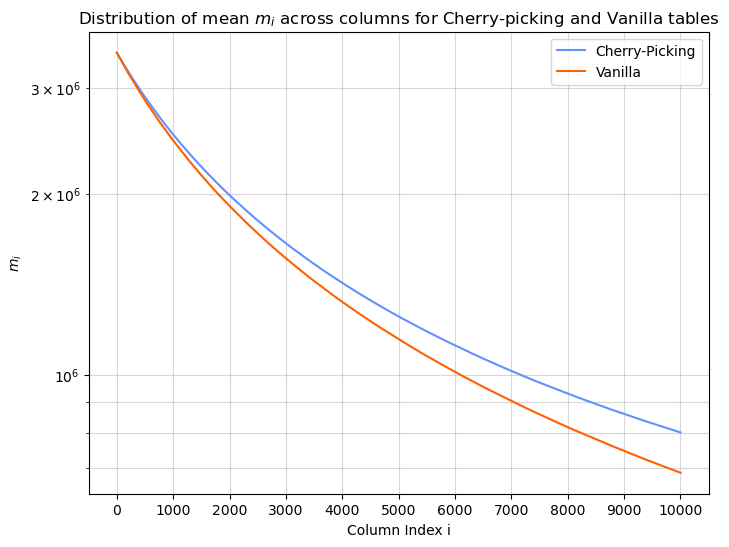

In [10]:
## Plot m_values for cherry and vanilla
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import LogLocator, LogFormatterMathtext

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)

ax = plt.gca()
ax.set_yscale('log')

# Force ticks only at integer powers of 10 (e.g., 10^0, 10^1, 10^2)
ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=10))
# Ensure they display nicely as 10^x
ax.yaxis.set_major_formatter(LogFormatterMathtext())

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)
# plt.grid(visible=True, which='major', axis='both', alpha=0.5)
# plt.grid(visible=True, which='minor', axis='y', alpha=0.2)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
plt.savefig("m_values_distribution_n_32.eps", format='eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


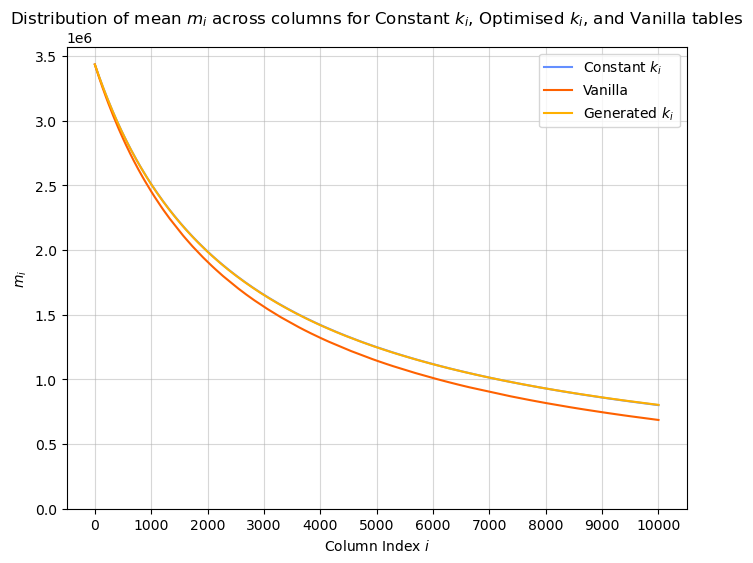

In [11]:
# add on k-curve one 

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Constant $k_i$", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)

curve_m_values_array = np.array(np.mean(curve_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, curve_m_values_array, color='#ffb000', label="Generated $k_i$", markersize=5)

ax = plt.gca()
# ax.set_yscale('log')

# Force ticks only at integer powers of 10 (e.g., 10^0, 10^1, 10^2)
# ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=10))
# # Ensure they display nicely as 10^x
# ax.yaxis.set_major_formatter(LogFormatterMathtext())

# add y ticks also where the curves end 
# # --- Add endpoint values as extra y-ticks ---
# end_vals = [cherry_m_values_array[-1], vanilla_m_values_array[-1], curve_m_values_array[-1]]
# end_colors = ['#648fff', '#FE6100', '#ffb000']

# # Save the natural limits BEFORE adding extra ticks
# y_min, y_max = ax.get_ylim()

# existing_ticks = ax.get_yticks(minor=False)
# new_ticks = np.concatenate([existing_ticks, end_vals])
# ax.set_yticks(new_ticks)
# ax.yaxis.set_major_formatter(LogFormatterMathtext())

# # Restore the original limits so the view doesn't change
# ax.set_ylim(y_min, y_max)

# # Colour the endpoint labels
# for tick_label, tick_val in zip(ax.get_yticklabels(), ax.get_yticks()):
#     for end_val, color in zip(end_vals, end_colors):
#         if np.isclose(tick_val, end_val, rtol=1e-6):
#             tick_label.set_color(color)
#             tick_label.set_fontweight('bold')

# end_vals_set = set(end_vals)

# def custom_formatter(val, pos):
#     for end_val in end_vals_set:
#         if np.isclose(val, end_val, rtol=1e-6):
#             return f'{val:.2f}'  # or f'{val:.3f}' for more decimal places
#     return LogFormatterMathtext()(val, pos)

# ax.yaxis.set_major_formatter(plt.FuncFormatter(custom_formatter))
# # --- end of addition --
ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)
# plt.grid(visible=True, which='major', axis='both', alpha=0.5)
# plt.grid(visible=True, which='minor', axis='y', alpha=0.2)
ax.set_ylim(ymin=0)


plt.xlabel(r"Column Index $i$")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Constant $k_i$, Optimised $k_i$, and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
plt.savefig("m_values_distribution_n_32_k_curve.eps", format='eps', bbox_inches='tight')
plt.show()

In [12]:
## success prob
ch_sp = 1 - ((1 - (cherry_avg_mt / 2**32)) ** t)
curve_sp = 1 - ((1 - (curve_avg_mt / 2**32)) ** t)
van_sp = 1 - ((1 - (vanilla_avg_mt / 2**32)) ** t)

print(f"Success probability of cherry: {ch_sp}")
print(f"Success probability of k-curve: {curve_sp}")
print(f"Success probability of vanilla: {van_sp}")

Success probability of cherry: 0.8451518617321353
Success probability of k-curve: 0.8458618498933477
Success probability of vanilla: 0.7977652561436454


In [13]:
def p_ell(p, ell):
    return 1 - ((1 - p) ** ell)

# figure out how many ell it takes to get to 99.97% success probability for both cherry and vanilla
cherry_ell = 0
curve_ell = 0
vanilla_ell = 0


for i in range(1, 7):
    p_cherry_ell = p_ell(ch_sp, i)
    p_curve_ell = p_ell(curve_sp, i)
    p_vanilla_ell = p_ell(van_sp, i)
    print(f"Success probability of cherry with ell={i}: {p_cherry_ell * 100:.4f}%")
    print(f"Success probability of k-curve with ell={i}: {p_curve_ell * 100:.4f}%")
    print(f"Success probability of vanilla with ell={i}: {p_vanilla_ell * 100:.4f}%\n")

Success probability of cherry with ell=1: 84.5152%
Success probability of k-curve with ell=1: 84.5862%
Success probability of vanilla with ell=1: 79.7765%

Success probability of cherry with ell=2: 97.6022%
Success probability of k-curve with ell=2: 97.6241%
Success probability of vanilla with ell=2: 95.9101%

Success probability of cherry with ell=3: 99.6287%
Success probability of k-curve with ell=3: 99.6338%
Success probability of vanilla with ell=3: 99.1729%

Success probability of cherry with ell=4: 99.9425%
Success probability of k-curve with ell=4: 99.9436%
Success probability of vanilla with ell=4: 99.8327%

Success probability of cherry with ell=5: 99.9911%
Success probability of k-curve with ell=5: 99.9913%
Success probability of vanilla with ell=5: 99.9662%

Success probability of cherry with ell=6: 99.9986%
Success probability of k-curve with ell=6: 99.9987%
Success probability of vanilla with ell=6: 99.9932%



In [14]:
print(cherry_avg_mt * 5)
print(curve_avg_mt * 5)
print(vanilla_avg_mt * 6)

4005350.0
4015217.1428571427
4118526.0


1185213.8817791939
1186884.8
1185050.364636898
1186752.6
-0.0014098031135931814
-0.0014364244878517216
0.9814669169986412


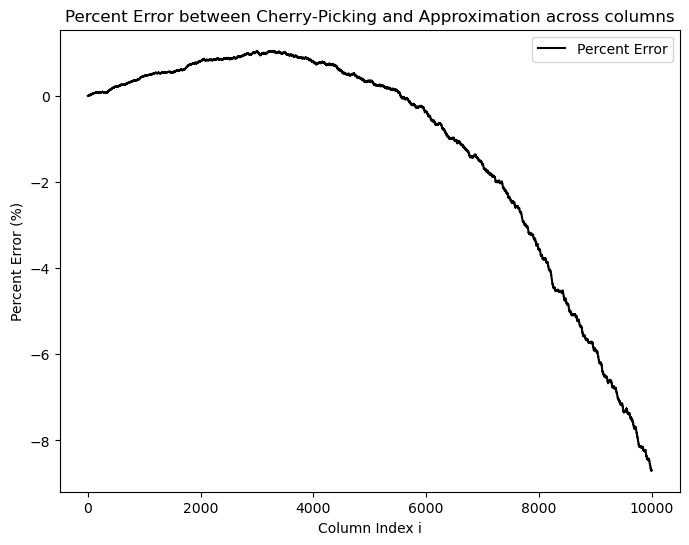

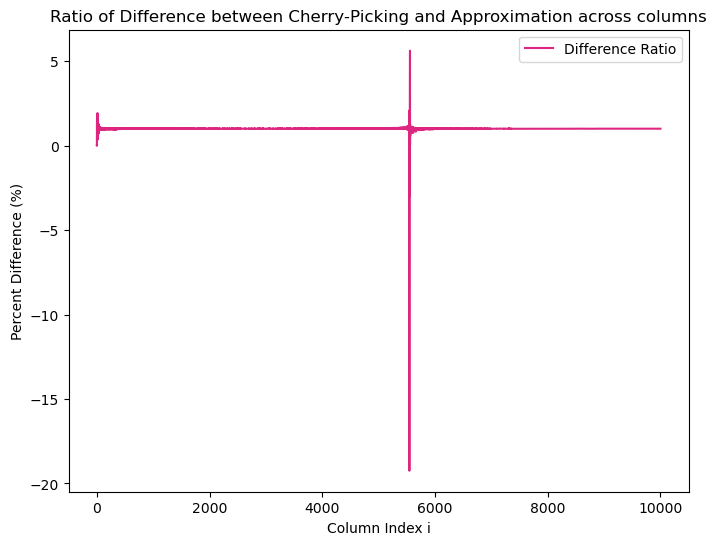

In [15]:
# find percent error between columns of cherry and approx
points_df = pd.DataFrame({
    "cherry": cherry_m_values_array,
    "approx": approx_m_values
})

points_df["percent_error"] = ((points_df["cherry"] - points_df["approx"]) / points_df["cherry"]) * 100

percent_difference = [0]
# for i in range(1, len(points_df)):
#     percent_difference.append(points_df["percent_error"].iloc[i-1] / points_df["percent_error"].iloc[i])
for i in range(1, len(points_df)):
    # [(approx_i-baseline_i)/approx_i] / [(approx_{i+1}-baseline_{i+1})/approx._{i+1}]
    percent_difference.append(((points_df["approx"].iloc[i-1] - points_df["cherry"].iloc[i-1] ) / points_df["approx"].iloc[i-1]) / ((points_df["approx"].iloc[i] - points_df["cherry"].iloc[i]) / points_df["approx"].iloc[i]))
    if i == 5448:
        print(points_df["approx"].iloc[i-1])
        print(points_df["cherry"].iloc[i-1])
        print(points_df["approx"].iloc[i])
        print(points_df["cherry"].iloc[i])
        print(((points_df["approx"].iloc[i-1] - points_df["cherry"].iloc[i-1] ) / points_df["approx"].iloc[i-1]))
        print(((points_df["approx"].iloc[i] - points_df["cherry"].iloc[i]) / points_df["approx"].iloc[i]))
        print(((points_df["approx"].iloc[i-1] - points_df["cherry"].iloc[i-1] ) / points_df["approx"].iloc[i-1]) / ((points_df["approx"].iloc[i] - points_df["cherry"].iloc[i]) / points_df["approx"].iloc[i]))


points_df["percent_difference"] = percent_difference

# import numpy as np

# # 1. Calculate the relative error for all rows at once
# # We add a tiny epsilon (e.g., 1e-15) if there's any chance approx itself is 0
# numerator_err = (points_df["approx"] - points_df["cherry"]) / points_df["approx"]

# # 2. Shift the series to get the "next" row's error for the denominator
# # This aligns row i with row i+1
# denominator_err = numerator_err.shift(-1)

# # 3. Handle the near-zero division safely
# # If the denominator error is extremely close to 0, replace it with NaN or 0 to prevent inf
# epsilon = 1e-12 
# safe_denominator = np.where(np.abs(denominator_err) < epsilon, np.nan, denominator_err)

# # 4. Calculate the final ratio
# points_df["percent_difference_ratio"] = numerator_err / safe_denominator

# plot percent error across columns
plt.figure(figsize=(8, 6))
plt.plot(x_indicies, points_df["percent_error"], color='#000000', label="Percent Error", markersize=5)
plt.xlabel("Column Index i")
plt.ylabel("Percent Error (%)")
plt.title("Percent Error between Cherry-Picking and Approximation across columns")
plt.legend()
plt.show()

# plot percent difference across columns
plt.figure(figsize=(8, 6))
plt.plot(x_indicies, points_df["percent_difference"], color='#dc267f', label="Difference Ratio", markersize=5)
plt.xlabel("Column Index i")
plt.ylabel("Percent Difference (%)")
plt.title("Ratio of Difference between Cherry-Picking and Approximation across columns")
plt.legend()
plt.show()

In [16]:
for item in percent_difference:
    print(item)

0
-0.011260117900720562
1.2565724407342813
1.4536755179612522
0.34891559556653995
1.1759162269130032
0.5531222259952543
1.1438657231478455
1.06007943359717
1.1331165245207513
1.1099737993221912
1.922277938928329
0.43981369811698584
1.1758331517296348
1.1908442440587834
1.3247713150402252
1.5563552406587469
0.3642696469766765
0.6239865524206798
1.0675802756819612
0.733939263678593
1.0778250511988214
1.0788854855928383
1.072949091351292
1.3290334116089926
0.6845843322331204
0.7587802447101962
1.2671036199566996
1.0745397617100183
1.1382583338076686
0.7248912224257508
0.792515133096219
0.8296420747765344
0.8502292033419223
1.135861862987184
1.042515088486143
0.841126268719042
0.8627576616179671
0.8803144343937983
1.0964321681146156
0.8879790975398151
0.9009684844068967
0.9130617545608957
1.0283126914766214
0.9113895529238877
1.0233398361679928
0.9123118005666095
1.0173346581665983
1.0193254346281428
0.9249282381163806
0.9202010511292803
1.099303601850571
0.923268499558945
1.02342487161025